In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# 2. CELL 2에서 경로 수정:
BASE_DIR = '/content/drive/MyDrive/가명정보활용경진대회'

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 40.5 MB/s eta 0:00:00
✅ 기본 라이브러리 로드 및 한글 폰트 설정 완료
✅ area: /content/drive/MyDrive/가명정보활용경진대회/서울시 상권분석서비스(영역-상권).csv
✅ sales_2021: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/서울시_상권분석서비스(추정매출-상권)_2021년.csv
✅ sales_2022: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/서울시_상권분석서비스(추정매출-상권)_2022년.csv
✅ sales_2023: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/서울시_상권분석서비스(추정매출-상권)_2023년.csv
✅ sales_2024: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/서울시 상권분석서비스(추정매출-상권)_2024년.csv
✅ sales_2025: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/서울시 상권분석서비스(추정매출-상권)_2025년.csv
✅ restaurant: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/식품_일반음식점.csv
✅ cafe: /content/drive/MyDrive/가명정보활용경진대회/학습 데이터/식품_휴게음식점.csv
📊 데이터 로딩 시작...
🗺️  상권 영역 데이터: (1650, 11)
💰 sales_2021: 89,150 rows
💰 sales_2022: 88,834 rows
💰 sales_2023: 88,246 rows
💰 sales_2024: 87,179 rows
💰 sales_2025: 85,732 rows
💰 전체 매출 데이터: 439,141 rows
🏪 서울 음식점 데이터: 682,491 rows

🔧 전처리 시작...
좌표 유효 업소 수: 642,339
2021-2022 폐업:

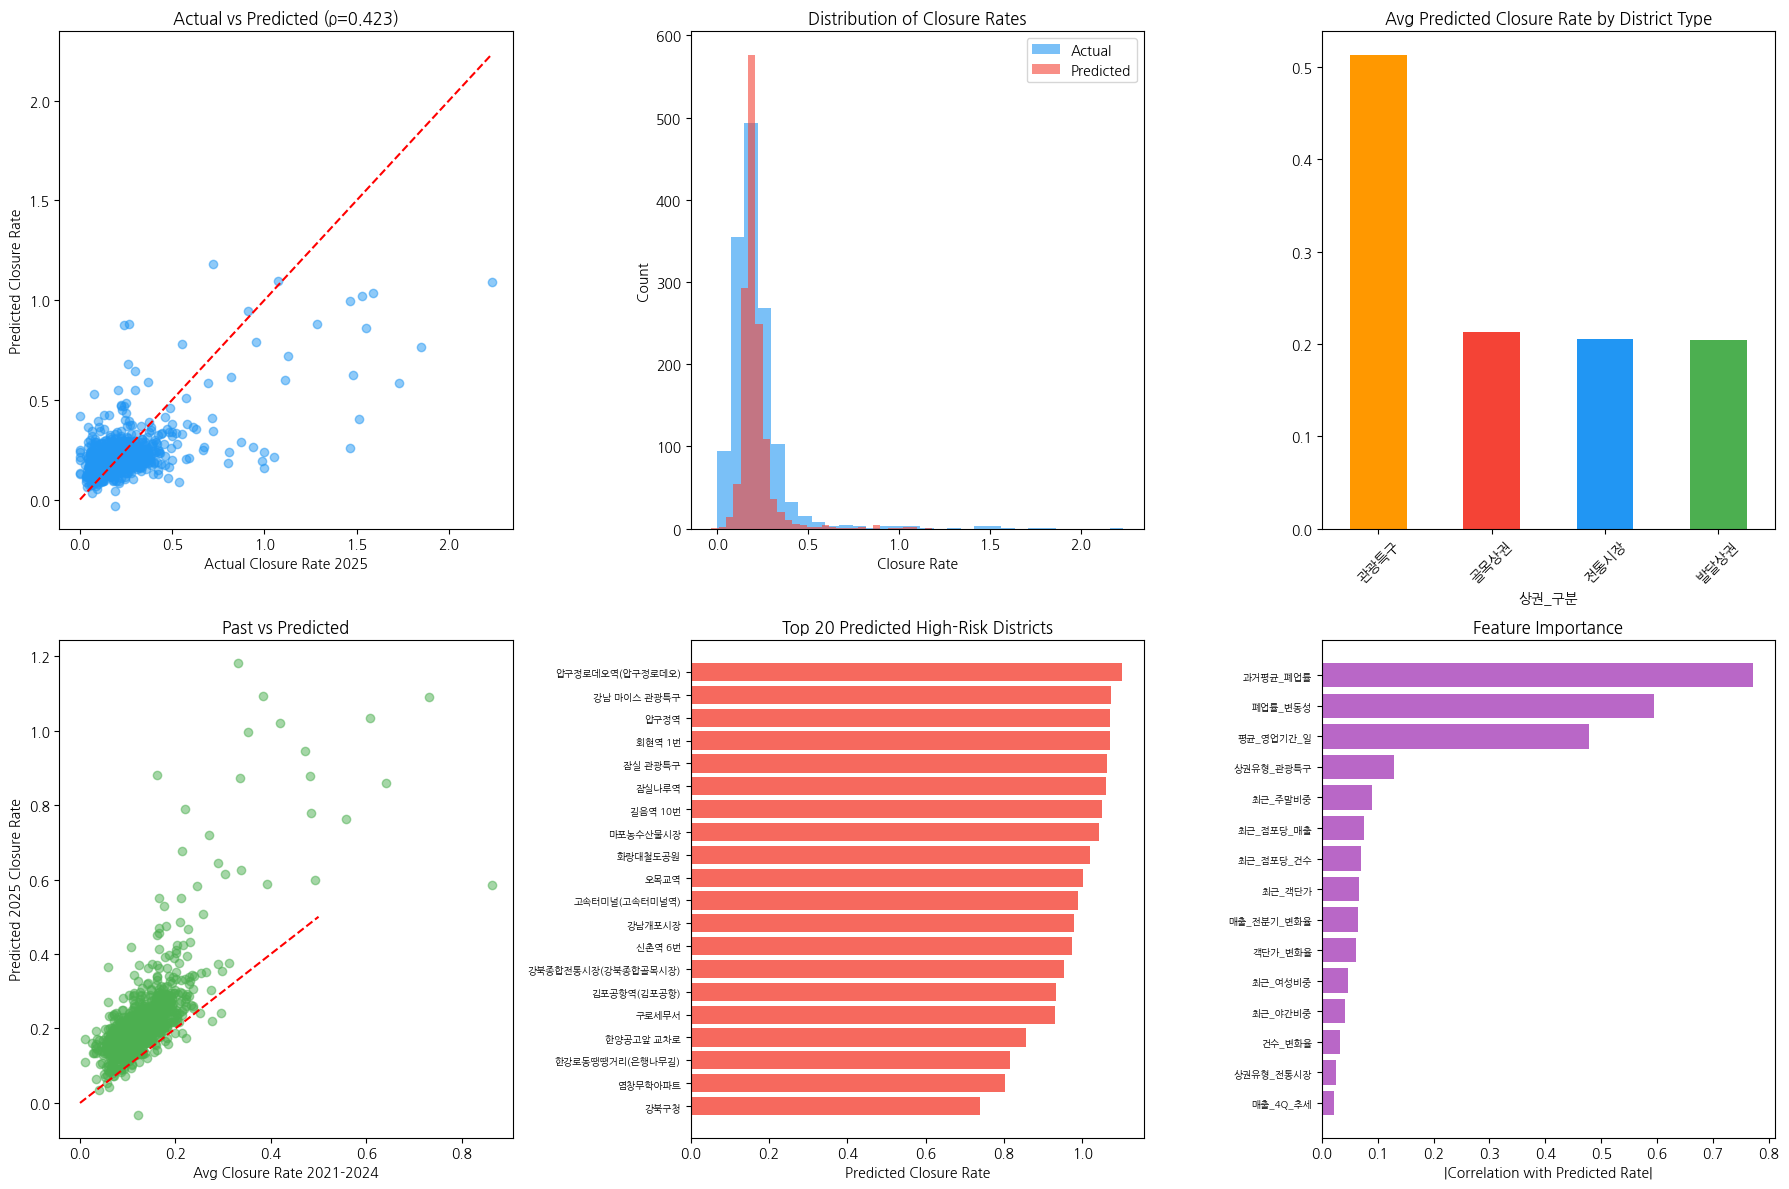

💾 예측 결과 저장: /content/drive/MyDrive/가명정보활용경진대회/early_warning_regression.csv
💾 모델 저장: /content/drive/MyDrive/가명정보활용경진대회/early_warning_regression_model.pt

🎉 회귀 기반 조기경보 파이프라인 완료!


In [ ]:
# -*- coding: utf-8 -*-
"""
===============================================================================
상권 조기경보 AI 모델 (Commercial District Early-Warning AI)
- 개선 버전: 회귀 예측 + 하이퍼파라미터 튜닝 & 앙상블
- Google Colab 실행용 전체 파이프라인
===============================================================================
"""

### CELL 1: 환경 설정 및 라이브러리 설치 =========================================
!pip install koreanize-matplotlib -q

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
print("✅ 기본 라이브러리 로드 및 한글 폰트 설정 완료")

### CELL 2: 데이터 경로 설정 =====================================================
BASE_DIR = '/content/drive/MyDrive/가명정보활용경진대회'
PATHS = {
    'area': os.path.join(BASE_DIR, '서울시 상권분석서비스(영역-상권).csv'),
    'sales_2021': os.path.join(BASE_DIR, '학습 데이터', '서울시_상권분석서비스(추정매출-상권)_2021년.csv'),
    'sales_2022': os.path.join(BASE_DIR, '학습 데이터', '서울시_상권분석서비스(추정매출-상권)_2022년.csv'),
    'sales_2023': os.path.join(BASE_DIR, '학습 데이터', '서울시_상권분석서비스(추정매출-상권)_2023년.csv'),
    'sales_2024': os.path.join(BASE_DIR, '학습 데이터', '서울시 상권분석서비스(추정매출-상권)_2024년.csv'),
    'sales_2025': os.path.join(BASE_DIR, '학습 데이터', '서울시 상권분석서비스(추정매출-상권)_2025년.csv'),
    'restaurant': os.path.join(BASE_DIR, '학습 데이터', '식품_일반음식점.csv'),
    'cafe': os.path.join(BASE_DIR, '학습 데이터', '식품_휴게음식점.csv'),
}
for name, path in PATHS.items():
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"{exists} {name}: {path}")

### CELL 3: 데이터 로딩 (변경 없음) ===============================================
print("=" * 60)
print("📊 데이터 로딩 시작...")
print("=" * 60)

df_area = pd.read_csv(PATHS['area'], encoding='cp949')
print(f"🗺️  상권 영역 데이터: {df_area.shape}")

sales_dfs = []
for year_key in ['sales_2021', 'sales_2022', 'sales_2023', 'sales_2024', 'sales_2025']:
    try:
        df = pd.read_csv(PATHS[year_key], encoding='cp949')
        sales_dfs.append(df)
        print(f"💰 {year_key}: {df.shape[0]:,} rows")
    except Exception as e:
        print(f"⚠️  {year_key} 로딩 실패: {e}")
df_sales_all = pd.concat(sales_dfs, ignore_index=True)
print(f"💰 전체 매출 데이터: {df_sales_all.shape[0]:,} rows")

df_restaurant = pd.read_csv(PATHS['restaurant'], encoding='cp949', low_memory=False)
df_cafe = pd.read_csv(PATHS['cafe'], encoding='cp949', low_memory=False)
df_restaurant = df_restaurant[df_restaurant['지번주소'].str.contains('서울', na=False)].copy()
df_cafe = df_cafe[df_cafe['지번주소'].str.contains('서울', na=False)].copy()
df_restaurant['업소구분'] = '일반음식점'
df_cafe['업소구분'] = '휴게음식점'
df_shops = pd.concat([df_restaurant, df_cafe], ignore_index=True)
print(f"🏪 서울 음식점 데이터: {df_shops.shape[0]:,} rows")

### CELL 4: 전처리 - 업소 데이터 (변경 없음) =======================================
print("\n" + "=" * 60)
print("🔧 전처리 시작...")
print("=" * 60)

df_shops['인허가일자'] = pd.to_datetime(df_shops['인허가일자'], errors='coerce')
df_shops['폐업일자'] = pd.to_datetime(df_shops['폐업일자'], errors='coerce')
df_shops['X'] = pd.to_numeric(df_shops['좌표정보(X)'].astype(str).str.strip(), errors='coerce')
df_shops['Y'] = pd.to_numeric(df_shops['좌표정보(Y)'].astype(str).str.strip(), errors='coerce')
df_shops = df_shops.dropna(subset=['X', 'Y'])
print(f"좌표 유효 업소 수: {df_shops.shape[0]:,}")

df_shops['is_closed'] = (df_shops['영업상태명'] == '폐업').astype(int)
df_shops['closed_2021_2022'] = (
    (df_shops['is_closed'] == 1) &
    (df_shops['폐업일자'] >= '2021-01-01') & (df_shops['폐업일자'] < '2023-01-01')
).astype(int)
df_shops['closed_2023_2024'] = (
    (df_shops['is_closed'] == 1) &
    (df_shops['폐업일자'] >= '2023-01-01') & (df_shops['폐업일자'] < '2025-01-01')
).astype(int)
df_shops['closed_2025'] = (
    (df_shops['is_closed'] == 1) & (df_shops['폐업일자'] >= '2025-01-01')
).astype(int)
print(f"2021-2022 폐업: {df_shops['closed_2021_2022'].sum():,}")
print(f"2023-2024 폐업: {df_shops['closed_2023_2024'].sum():,}")
print(f"2025 폐업: {df_shops['closed_2025'].sum():,}")

### CELL 5: 업소 → 상권 매핑 (변경 없음) ==========================================
from scipy.spatial import cKDTree
area_coords = df_area[['엑스좌표_값', '와이좌표_값']].values.astype(float)
area_tree = cKDTree(area_coords)
shop_coords = df_shops[['X', 'Y']].values.astype(float)
distances, indices = area_tree.query(shop_coords, k=1)

df_shops['상권_코드'] = df_area.iloc[indices]['상권_코드'].values
df_shops['상권_코드_명'] = df_area.iloc[indices]['상권_코드_명'].values
df_shops['상권_구분'] = df_area.iloc[indices]['상권_구분_코드_명'].values
df_shops['거리_to_상권'] = distances
df_shops = df_shops[df_shops['거리_to_상권'] < 2000].copy()
print(f"매핑 완료: {df_shops.shape[0]:,} 업소 → {df_shops['상권_코드'].nunique()} 상권")

### CELL 6: 상권별 폐업 통계 집계 (변경 없음, 타겟 컬럼만 추가) ====================
print("\n" + "=" * 60)
print("📈 상권별 폐업 통계 집계...")
print("=" * 60)

def get_active_mask(df, as_of_date):
    return (df['인허가일자'] < as_of_date) & ((df['is_closed'] == 0) | (df['폐업일자'] >= as_of_date))

def get_closed_mask(df, start_date, end_date):
    return (df['is_closed'] == 1) & (df['폐업일자'] >= start_date) & (df['폐업일자'] < end_date)

years = [2021, 2022, 2023, 2024, 2025]
for y in years:
    df_shops[f'영업중_{y-1}말'] = get_active_mask(df_shops, f'{y}-01-01').astype(int)
    end_date = f'{y+1}-01-01' if y < 2025 else '2099-01-01'
    df_shops[f'폐업_{y}'] = get_closed_mask(df_shops, f'{y}-01-01', end_date).astype(int)

def mean_operating_days(x):
    valid = x.dropna()
    if len(valid) == 0:
        return 0
    return (datetime(2024, 12, 31) - valid).dt.days.mean()

agg_dict = {
    'is_closed': 'count',
    '인허가일자': mean_operating_days,
    '상권_구분': 'first',
}
for y in years:
    agg_dict[f'영업중_{y-1}말'] = 'sum'
    agg_dict[f'폐업_{y}'] = 'sum'

district_stats = df_shops.groupby('상권_코드').agg(agg_dict).reset_index()
district_stats.rename(columns={'is_closed': '총_업소수', '인허가일자': '평균_영업기간_일'}, inplace=True)

MIN_SHOPS = 10
district_stats = district_stats[district_stats['영업중_2024말'] >= MIN_SHOPS].copy()

for y in years:
    district_stats[f'폐업률_{y}'] = (
        district_stats[f'폐업_{y}'] / district_stats[f'영업중_{y-1}말'].replace(0, np.nan)
    )
district_stats = district_stats.fillna(0)

district_stats['과거평균_폐업률'] = district_stats[[f'폐업률_{y}' for y in [2021,2022,2023,2024]]].mean(axis=1)
district_stats['폐업률_변동성'] = district_stats[[f'폐업률_{y}' for y in [2021,2022,2023,2024]]].std(axis=1)
district_stats['폐업률_변화량_2025'] = district_stats['폐업률_2025'] - district_stats['과거평균_폐업률']

# 회귀 타겟: 폐업률_2025 (0~1 사이) -> 예측 대상
# GT 이진 라벨은 별도 기준으로 유지 (평가용)
threshold_gt = district_stats['폐업률_2025'].quantile(0.8)
district_stats['gt_2025_위험'] = (district_stats['폐업률_2025'] >= threshold_gt).astype(int)

print(f"필터링 후 상권 수: {district_stats.shape[0]}")

### CELL 7: 매출 피처 엔지니어링 (변경 없음) ======================================
print("\n" + "=" * 60)
print("⚙️  매출 피처 엔지니어링...")
print("=" * 60)

df_sales_all['서비스_업종_코드'] = df_sales_all['서비스_업종_코드'].astype(str).str.strip('"')
df_sales_food = df_sales_all[df_sales_all['서비스_업종_코드'].str.startswith('CS1')].copy()
df_sales_food['기준_년분기_코드'] = df_sales_food['기준_년분기_코드'].astype(str).str.strip('"')
df_sales_food['상권_코드'] = df_sales_food['상권_코드'].astype(str).str.strip('"').astype(int)

numeric_cols = [
    '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액',
    '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
    '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액',
    '남성_매출_금액', '여성_매출_금액',
    '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
    '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액',
    '주중_매출_건수', '주말_매출_건수'
]
for col in numeric_cols:
    df_sales_food[col] = pd.to_numeric(
        df_sales_food[col].astype(str).str.strip('"'), errors='coerce'
    ).fillna(0)

sales_agg = df_sales_food.groupby(['상권_코드', '기준_년분기_코드']).agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    주중매출=('주중_매출_금액', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    남성매출=('남성_매출_금액', 'sum'),
    여성매출=('여성_매출_금액', 'sum'),
    청년매출=('연령대_20_매출_금액', 'sum'),
    중장년매출=('연령대_40_매출_금액', 'sum'),
    시니어매출=('연령대_60_이상_매출_금액', 'sum'),
    업종수=('서비스_업종_코드', 'nunique'),
).reset_index()

sales_agg['객단가'] = (sales_agg['총매출'] / sales_agg['총건수'].replace(0, np.nan)).fillna(0)
sales_agg['주말비중'] = (sales_agg['주말매출'] / sales_agg['총매출'].replace(0, np.nan)).fillna(0)
sales_agg['야간비중'] = (sales_agg['야간매출'] / sales_agg['총매출'].replace(0, np.nan)).fillna(0)
sales_agg['저녁비중'] = (sales_agg['저녁매출'] / sales_agg['총매출'].replace(0, np.nan)).fillna(0)
sales_agg['여성비중'] = (sales_agg['여성매출'] / sales_agg['총매출'].replace(0, np.nan)).fillna(0)
sales_agg['시니어비중'] = (sales_agg['시니어매출'] / sales_agg['총매출'].replace(0, np.nan)).fillna(0)

sales_agg['연도'] = sales_agg['기준_년분기_코드'].str[:4].astype(int)
sales_agg = sales_agg.merge(
    district_stats[['상권_코드'] + [f'영업중_{y}말' for y in range(2020, 2025)]],
    on='상권_코드', how='inner'
)

def get_active_shops(row):
    y = row['연도']
    if y <= 2021: return row['영업중_2020말']
    elif y == 2022: return row['영업중_2021말']
    elif y == 2023: return row['영업중_2022말']
    elif y == 2024: return row['영업중_2023말']
    else: return row['영업중_2024말']

sales_agg['해당연도_영업중'] = sales_agg.apply(get_active_shops, axis=1).replace(0, 1)
sales_agg['점포당_매출'] = sales_agg['총매출'] / sales_agg['해당연도_영업중']
sales_agg['점포당_건수'] = sales_agg['총건수'] / sales_agg['해당연도_영업중']
print(f"매출 집계: {sales_agg.shape[0]:,} rows")

### CELL 8: 시계열 피처 생성 (변경 없음) ==========================================
print("\n" + "=" * 60)
print("📉 시계열 피처 생성...")
print("=" * 60)

quarter_order = sorted(sales_agg['기준_년분기_코드'].unique())
quarter_map = {q: i for i, q in enumerate(quarter_order)}
sales_agg['분기순서'] = sales_agg['기준_년분기_코드'].map(quarter_map)
sales_agg = sales_agg.sort_values(['상권_코드', '분기순서'])

def compute_temporal_features(group):
    features = {}
    if len(group) >= 2:
        recent = group['점포당_매출'].iloc[-1]
        prev = group['점포당_매출'].iloc[-2]
        features['매출_전분기_변화율'] = (recent - prev) / max(prev, 1)
    else:
        features['매출_전분기_변화율'] = 0
    if len(group) >= 4:
        last4 = group['점포당_매출'].iloc[-4:].values
        x = np.arange(4)
        if np.std(last4) > 0:
            slope = np.polyfit(x, last4, 1)[0]
            features['매출_4Q_추세'] = slope / max(np.mean(last4), 1)
        else:
            features['매출_4Q_추세'] = 0
    else:
        features['매출_4Q_추세'] = 0
    if len(group) >= 3:
        cv = group['점포당_매출'].std() / max(group['점포당_매출'].mean(), 1)
        features['매출_변동성'] = cv
    else:
        features['매출_변동성'] = 0
    if len(group) >= 2:
        features['객단가_변화율'] = (group['객단가'].iloc[-1] - group['객단가'].iloc[-2]) / max(group['객단가'].iloc[-2], 1)
        features['건수_변화율'] = (group['점포당_건수'].iloc[-1] - group['점포당_건수'].iloc[-2]) / max(group['점포당_건수'].iloc[-2], 1)
    else:
        features['객단가_변화율'] = 0
        features['건수_변화율'] = 0
    features['최근_점포당_매출'] = group['점포당_매출'].iloc[-1]
    features['최근_점포당_건수'] = group['점포당_건수'].iloc[-1]
    features['최근_객단가'] = group['객단가'].iloc[-1]
    features['최근_주말비중'] = group['주말비중'].iloc[-1]
    features['최근_야간비중'] = group['야간비중'].iloc[-1]
    features['최근_저녁비중'] = group['저녁비중'].iloc[-1]
    features['최근_여성비중'] = group['여성비중'].iloc[-1]
    features['최근_시니어비중'] = group['시니어비중'].iloc[-1]
    features['최근_업종수'] = group['업종수'].iloc[-1]
    return pd.Series(features)

sales_train = sales_agg[sales_agg['기준_년분기_코드'] <= '20244']
temporal_features = sales_train.groupby('상권_코드').apply(compute_temporal_features).reset_index()
print(f"학습용 시계열 피처: {temporal_features.shape}")

### CELL 9: 최종 학습 데이터 병합 (타겟 회귀 값 추가) ================================
print("\n" + "=" * 60)
print("🔀 최종 학습 데이터 병합...")
print("=" * 60)

area_info = df_area[['상권_코드', '상권_코드_명', '엑스좌표_값', '와이좌표_값',
                     '영역_면적', '상권_구분_코드_명', '자치구_코드_명']].copy()
area_info['log_면적'] = np.log1p(area_info['영역_면적'])
area_info.rename(columns={'상권_구분_코드_명': '상권_구분'}, inplace=True)
area_dummies = pd.get_dummies(area_info['상권_구분'], prefix='상권유형')
area_info = pd.concat([area_info, area_dummies], axis=1)

# district_stats에서 '상권_구분' 컬럼 충돌 방지
if '상권_구분' in district_stats.columns:
    district_stats = district_stats.drop(columns=['상권_구분'])

df_train = (
    district_stats
    .merge(area_info, on='상권_코드', how='inner')
    .merge(temporal_features, on='상권_코드', how='inner')
)

# 회귀 타겟: 2025년 폐업률 (0~1)
df_train['target_regression'] = df_train['폐업률_2025']

print(f"최종 학습 데이터: {df_train.shape}")
print(f"타겟(폐업률) 평균: {df_train['target_regression'].mean():.4f}, 표준편차: {df_train['target_regression'].std():.4f}")

### CELL 10: 시계열 입력 텐서 생성 (변경 없음) ====================================
SEQUENCE_LENGTH = 8
ts_features = ['점포당_매출', '점포당_건수', '객단가', '주말비중', '야간비중',
               '저녁비중', '여성비중', '시니어비중', '업종수']

def create_sequences(sales_agg, district_codes, seq_len=8, cutoff_quarter='20244'):
    sequences = []
    valid_codes = []
    filtered = sales_agg[sales_agg['기준_년분기_코드'] <= cutoff_quarter]
    for code in district_codes:
        district_data = filtered[filtered['상권_코드'] == code].sort_values('분기순서')
        if len(district_data) < 4:
            continue
        seq = district_data[ts_features].values[-seq_len:]
        if len(seq) < seq_len:
            pad = np.zeros((seq_len - len(seq), len(ts_features)))
            seq = np.vstack([pad, seq])
        sequences.append(seq)
        valid_codes.append(code)
    return np.array(sequences), valid_codes

sequences, valid_codes = create_sequences(
    sales_agg, df_train['상권_코드'].values, SEQUENCE_LENGTH, '20244'
)
print(f"시퀀스 shape: {sequences.shape}")

df_train = df_train[df_train['상권_코드'].isin(valid_codes)].copy()
code_to_idx = {c: i for i, c in enumerate(valid_codes)}
df_train['seq_idx'] = df_train['상권_코드'].map(code_to_idx)
df_train = df_train.sort_values('seq_idx').reset_index(drop=True)
print(f"최종 학습 데이터: {df_train.shape}")

### CELL 11: 공간 그래프 구성 (변경 없음) =========================================
print("\n" + "=" * 60)
print("🕸️  공간 그래프 구성...")
print("=" * 60)

graph_coords = df_train[['엑스좌표_값', '와이좌표_값']].values.astype(float)
K_NEIGHBORS = 5
tree = cKDTree(graph_coords)
distances, neighbors = tree.query(graph_coords, k=K_NEIGHBORS + 1)

edge_src, edge_dst, edge_weight = [], [], []
for i in range(len(graph_coords)):
    for j in range(1, K_NEIGHBORS + 1):
        neighbor_idx = neighbors[i][j]
        dist = distances[i][j]
        if dist < 3000:
            edge_src.append(i)
            edge_dst.append(neighbor_idx)
            edge_weight.append(np.exp(-dist / 1000))

edge_src_bi = edge_src + edge_dst
edge_dst_bi = edge_dst + edge_src
edge_weight_bi = edge_weight + edge_weight
print(f"노드 수: {len(graph_coords)}, 엣지 수: {len(edge_src_bi)}")

### CELL 12: PyTorch 모델 정의 (회귀 출력으로 수정) ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

try:
    from torch_geometric.nn import GCNConv, GATConv
    HAS_PYG = True
    print("✅ PyTorch Geometric 사용 가능")
except ImportError:
    HAS_PYG = False
    print("⚠️  PyTorch Geometric 없음 → MLP+LSTM 대체")

class TemporalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        self.output_dim = hidden_dim * 2

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out)
        attn_weights = F.softmax(attn_weights, dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return context

class SpatialGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, heads=4):
        super().__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.3)
        self.norm1 = nn.LayerNorm(hidden_dim * heads)
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_attr=None):
        h = self.conv1(x, edge_index)
        h = self.norm1(h)
        h = F.elu(h)
        h = F.dropout(h, p=0.3, training=self.training)
        h = self.conv2(h, edge_index)
        h = self.norm2(h)
        h = F.elu(h)
        return h

class SpatialMLPFallback(nn.Module):
    # 변경: neighbor_dim 파라미터 추가
    def __init__(self, input_dim, neighbor_dim, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            # 변경: input_dim * 2 -> input_dim + neighbor_dim
            nn.Linear(input_dim + neighbor_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
        )
        self.output_dim = hidden_dim

    def forward(self, x, neighbor_features):
        combined = torch.cat([x, neighbor_features], dim=-1)
        return self.mlp(combined)

class EarlyWarningModel(nn.Module):
    def __init__(self, ts_dim, static_dim, hidden_dim=64, use_gnn=True):
        super().__init__()
        self.use_gnn = use_gnn
        self.hidden_dim = hidden_dim

        self.temporal = TemporalEncoder(ts_dim, hidden_dim)
        spatial_input_dim = self.temporal.output_dim + static_dim

        if use_gnn and HAS_PYG:
            self.spatial = SpatialGNN(spatial_input_dim, hidden_dim)
            spatial_out = hidden_dim
        else:
            # 변경: neighbor_dim을 직접 계산하여 전달
            neighbor_dim = ts_dim + static_dim
            self.spatial = SpatialMLPFallback(spatial_input_dim, neighbor_dim, hidden_dim)
            spatial_out = hidden_dim

        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Dropout(0.2),
        )

        fusion_dim = self.temporal.output_dim + spatial_out + hidden_dim
        # 회귀 출력: 1개의 연속값 (폐업률)
        self.regressor = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1),
        )

        # 보조 태스크: 매출 예측
        self.sales_predictor = nn.Sequential(
            nn.Linear(self.temporal.output_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, ts_input, static_input, edge_index=None, edge_attr=None, neighbor_features=None):
        temporal_emb = self.temporal(ts_input)
        static_emb = self.static_encoder(static_input)
        node_feat = torch.cat([temporal_emb, static_input], dim=-1)
        if self.use_gnn and HAS_PYG and edge_index is not None:
            spatial_emb = self.spatial(node_feat, edge_index, edge_attr)
        elif neighbor_features is not None:
            spatial_emb = self.spatial(node_feat, neighbor_features)
        else:
            spatial_emb = self.spatial.mlp[:4](node_feat)
        fused = torch.cat([temporal_emb, spatial_emb, static_emb], dim=-1)
        closure_rate = self.regressor(fused)          # shape: (N,1)
        sales_pred = self.sales_predictor(temporal_emb)  # shape: (N,1)
        return closure_rate, sales_pred

print("✅ 모델 정의 완료 (회귀 출력)")

### CELL 13: 학습 데이터 준비 (회귀 타겟 적용) =====================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr, pearsonr

static_feature_cols = [
    '과거평균_폐업률', '폐업률_변동성', '평균_영업기간_일',
    '매출_전분기_변화율', '매출_4Q_추세', '매출_변동성',
    '객단가_변화율', '건수_변화율', '최근_점포당_매출', '최근_점포당_건수',
    '최근_객단가', '최근_주말비중', '최근_야간비중', '최근_저녁비중',
    '최근_여성비중', '최근_시니어비중', '최근_업종수',
]
onehot_cols = [c for c in df_train.columns if c.startswith('상권유형_')]
static_feature_cols += [c for c in onehot_cols if c in df_train.columns and df_train[c].dtype in ['int64', 'float64', 'bool', 'uint8']]

df_train[static_feature_cols] = df_train[static_feature_cols].fillna(0)
scaler_static = StandardScaler()
static_scaled = scaler_static.fit_transform(df_train[static_feature_cols].values)

scaler_ts = StandardScaler()
seq_reshaped = sequences.reshape(-1, sequences.shape[-1])
seq_scaled = scaler_ts.fit_transform(seq_reshaped).reshape(sequences.shape)

# 회귀 타겟: 폐업률 2025
y_regression = df_train['target_regression'].values.astype(np.float32)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_regression.reshape(-1, 1)).flatten()

# 보조 타겟: 매출 (그대로)
y_sales = df_train['최근_점포당_매출'].values
scaler_sales = StandardScaler()
y_sales_scaled = scaler_sales.fit_transform(y_sales.reshape(-1, 1)).flatten()

X_ts = torch.FloatTensor(seq_scaled)
X_static = torch.FloatTensor(static_scaled)
Y_target = torch.FloatTensor(y_scaled)          # 회귀 타겟
Y_sales = torch.FloatTensor(y_sales_scaled)

edge_index = torch.LongTensor([edge_src_bi, edge_dst_bi])
edge_attr = torch.FloatTensor(edge_weight_bi).unsqueeze(1)

# 이웃 피처 (MLP fallback 용)
neighbor_static = torch.zeros_like(X_static)
for i in range(len(graph_coords)):
    nbr_indices = [edge_dst_bi[j] for j in range(len(edge_src_bi)) if edge_src_bi[j] == i]
    if nbr_indices:
        neighbor_static[i] = X_static[nbr_indices].mean(dim=0)

print(f"회귀 타겟 스케일링 완료: 평균={y_scaled.mean():.3f}, std={y_scaled.std():.3f}")

### CELL 14: 하이퍼파라미터 튜닝 (수정) =========================================
# CELL 14 진입 직전에 추가 (디버깅)
print("=== DEBUG: tensor shapes ===")
print("X_ts:", X_ts.shape)
print("X_static:", X_static.shape)
print("Y_target:", Y_target.shape)
print("edge_index:", edge_index.shape)
print("neighbor_static:", neighbor_static.shape)
static_dim_actual = X_static.shape[1]
print(f"static_dim_actual = {static_dim_actual}")

print("\n" + "=" * 60)
print("🔍 하이퍼파라미터 탐색 및 교차 검증 (회귀)")
print("=" * 60)

param_grid = {
    'lr': [1e-3, 5e-4],
    'hidden_dim': [32, 64],
    'use_gnn': [True, False] if HAS_PYG else [False]
}

skf = KFold(n_splits=5, shuffle=True, random_state=42)
first_fold_idx = list(skf.split(X_static))[0]
train_idx0, val_idx0 = first_fold_idx

best_score = float('inf')
best_params = None
print("   그리드 서치 시작...")

# 실제 static_dim 확인 (루프 전에 고정)
static_dim_actual = X_static.shape[1]
print(f"   static feature dimension = {static_dim_actual}")

for lr in param_grid['lr']:
    for hd in param_grid['hidden_dim']:
        for use_gnn in param_grid['use_gnn']:
            if use_gnn and not HAS_PYG:
                continue

            # 모델 생성
            model = EarlyWarningModel(
                ts_dim=len(ts_features),
                static_dim=static_dim_actual,   # 강제로 정확한 값 사용
                hidden_dim=hd,
                use_gnn=use_gnn
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
            mse_loss = nn.MSELoss()

            # 장치로 데이터 이동
            X_ts_d = X_ts.to(device)
            X_static_d = X_static.to(device)  # (N, static_dim_actual)
            Y_target_d = Y_target.to(device)
            Y_sales_d = Y_sales.to(device)
            edge_index_d = edge_index.to(device) if use_gnn else None
            edge_attr_d = edge_attr.to(device) if use_gnn else None

            # neighbor features (MLP fallback 용)
            nbr_concat = torch.cat([X_ts_d.mean(dim=1), X_static_d], dim=-1)
            neighbor_feat = torch.zeros_like(nbr_concat)
            for i in range(len(graph_coords)):
                nbrs = [edge_dst_bi[j] for j in range(len(edge_src_bi)) if edge_src_bi[j] == i]
                if nbrs:
                    neighbor_feat[i] = nbr_concat[nbrs].mean(dim=0)

            train_idx0_t = torch.LongTensor(train_idx0).to(device)
            val_idx0_t = torch.LongTensor(val_idx0).to(device)

            # 빠른 학습 (50에폭)
            for epoch in range(50):
                model.train()
                optimizer.zero_grad()
                pred, sales_pred = model(
                    X_ts_d, X_static_d,
                    edge_index=edge_index_d,
                    edge_attr=edge_attr_d,
                    neighbor_features=neighbor_feat if not use_gnn else None
                )
                loss = (
                    mse_loss(pred.squeeze()[train_idx0_t], Y_target_d[train_idx0_t])
                    + 0.1 * mse_loss(sales_pred.squeeze()[train_idx0_t], Y_sales_d[train_idx0_t])
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            # 검증 손실 계산
            model.eval()
            with torch.no_grad():
                pred_val, _ = model(
                    X_ts_d, X_static_d,
                    edge_index=edge_index_d,
                    edge_attr=edge_attr_d,
                    neighbor_features=neighbor_feat if not use_gnn else None
                )
                val_loss = mse_loss(pred_val.squeeze()[val_idx0_t], Y_target_d[val_idx0_t]).item()

            print(f"      lr={lr}, hd={hd}, gnn={use_gnn} -> val_loss={val_loss:.4f}")

            if val_loss < best_score:
                best_score = val_loss
                best_params = {'lr': lr, 'hidden_dim': hd, 'use_gnn': use_gnn}

print(f"\n✅ 최적 하이퍼파라미터: {best_params}")

### CELL 15: 최종 K-Fold 학습 및 앙상블 (회귀) =====================================
print("\n" + "=" * 60)
print("🚀 최종 교차 검증 및 앙상블 학습")
print("=" * 60)

# 최적 파라미터 적용
BEST_LR = best_params['lr']
BEST_HD = best_params['hidden_dim']
USE_GNN_BEST = best_params['use_gnn']

N_FOLDS = 5
EPOCHS = 150
PATIENCE = 20

fold_results = []
best_models = []
all_fold_preds = np.zeros(len(df_train))   # 앙상블 예측 저장

for fold, (train_idx, val_idx) in enumerate(skf.split(X_static)):
    print(f"\n{'─'*40}\n📂 Fold {fold+1}/{N_FOLDS}")

    model = EarlyWarningModel(
        ts_dim=len(ts_features), static_dim=X_static.shape[1],
        hidden_dim=BEST_HD, use_gnn=USE_GNN_BEST
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    mse_loss = nn.MSELoss()

    X_ts_d = X_ts.to(device); X_static_d = X_static.to(device)
    Y_target_d = Y_target.to(device); Y_sales_d = Y_sales.to(device)
    edge_index_d = edge_index.to(device) if USE_GNN_BEST else None
    edge_attr_d = edge_attr.to(device) if USE_GNN_BEST else None

    nbr_concat = torch.cat([X_ts_d.mean(dim=1), X_static_d], dim=-1)
    neighbor_feat = torch.zeros_like(nbr_concat)
    for i in range(len(graph_coords)):
        nbrs = [edge_dst_bi[j] for j in range(len(edge_src_bi)) if edge_src_bi[j] == i]
        if nbrs:
            neighbor_feat[i] = nbr_concat[nbrs].mean(dim=0)

    train_idx_t = torch.LongTensor(train_idx).to(device)
    val_idx_t = torch.LongTensor(val_idx).to(device)

    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        pred, sales_pred = model(X_ts_d, X_static_d, edge_index=edge_index_d,
                                 edge_attr=edge_attr_d,
                                 neighbor_features=neighbor_feat if not USE_GNN_BEST else None)
        loss = (
            mse_loss(pred.squeeze()[train_idx_t], Y_target_d[train_idx_t])
            + 0.1 * mse_loss(sales_pred.squeeze()[train_idx_t], Y_sales_d[train_idx_t])
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            pred_val, _ = model(X_ts_d, X_static_d, edge_index=edge_index_d,
                                edge_attr=edge_attr_d,
                                neighbor_features=neighbor_feat if not USE_GNN_BEST else None)
            val_loss = mse_loss(pred_val.squeeze()[val_idx_t], Y_target_d[val_idx_t]).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"⏹️ Early stopping at epoch {epoch+1}")
                break
        if (epoch+1) % 30 == 0:
            # val_loss는 이미 float이므로 .item() 제거
            print(f"Epoch {epoch+1}: train_loss={loss.item():.4f}, val_loss={val_loss:.4f}")

    model.load_state_dict(best_state)
    best_models.append(model)

    # 검증 세트 예측 (스케일 역변환)
    model.eval()
    with torch.no_grad():
        pred_val, _ = model(X_ts_d, X_static_d, edge_index=edge_index_d,
                            edge_attr=edge_attr_d,
                            neighbor_features=neighbor_feat if not USE_GNN_BEST else None)
        pred_val_np = pred_val.squeeze().cpu().numpy()
        pred_val_orig = scaler_y.inverse_transform(pred_val_np.reshape(-1, 1)).flatten()
        true_val_orig = y_regression[val_idx]

    rmse = np.sqrt(mean_squared_error(true_val_orig, pred_val_orig[val_idx]))
    mae = mean_absolute_error(true_val_orig, pred_val_orig[val_idx])
    corr_s, _ = spearmanr(true_val_orig, pred_val_orig[val_idx])
    corr_p, _ = pearsonr(true_val_orig, pred_val_orig[val_idx])

    fold_results.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'spearman': corr_s, 'pearson': corr_p})
    all_fold_preds[val_idx] = pred_val_orig[val_idx]
    print(f"📊 Fold {fold+1}: RMSE={rmse:.4f}, MAE={mae:.4f}, Spearman ρ={corr_s:.4f}, Pearson r={corr_p:.4f}")

print("\n📊 K-Fold 회귀 결과 요약")
res_df = pd.DataFrame(fold_results)
for m in ['rmse', 'mae', 'spearman', 'pearson']:
    print(f"{m:>10}: {res_df[m].mean():.4f} ± {res_df[m].std():.4f}")

# 전체 데이터에 대한 앙상블 예측 (5개 모델 평균)
all_test_preds = np.zeros(len(df_train))
for model in best_models:
    model.eval()
    with torch.no_grad():
        pred, _ = model(X_ts.to(device), X_static.to(device),
                        edge_index=edge_index.to(device) if USE_GNN_BEST else None,
                        edge_attr=edge_attr.to(device) if USE_GNN_BEST else None,
                        neighbor_features=neighbor_feat.to(device) if not USE_GNN_BEST else None)
        all_test_preds += pred.squeeze().cpu().numpy()
all_test_preds /= len(best_models)
df_train['pred_closure_rate'] = scaler_y.inverse_transform(all_test_preds.reshape(-1, 1)).flatten()
df_train['risk_score'] = df_train['pred_closure_rate']  # 예측 폐업률 자체가 위험도

print(f"\n✅ 앙상블 예측 완료, 예측 폐업률 평균: {df_train['pred_closure_rate'].mean():.4f}")

### CELL 16: GT 검증 (회귀 관점) ==================================================
print("\n" + "=" * 60)
print("✅ GT 검증 (2025년 실제 폐업률 vs 예측)")
print("=" * 60)

df_train['pred_closure_rate_oof'] = all_fold_preds
df_train['risk_score_oof'] = df_train['pred_closure_rate_oof']

y_true = df_train['폐업률_2025'].values
y_pred = df_train['pred_closure_rate_oof'].values  # OOF 예측값으로 평가 수행

rmse_all = np.sqrt(mean_squared_error(y_true, y_pred))
mae_all = mean_absolute_error(y_true, y_pred)
sp_corr, _ = spearmanr(y_true, y_pred)
pr_corr, _ = pearsonr(y_true, y_pred)

print(f"   전체 RMSE: {rmse_all:.4f}")
print(f"   전체 MAE : {mae_all:.4f}")
print(f"   Spearman ρ: {sp_corr:.4f}")
print(f"   Pearson r : {pr_corr:.4f}")

# 이진 GT 평가 (참고용)
gt_labels = df_train['gt_2025_위험'].values
optimal_threshold = np.percentile(y_pred, 80)
pred_labels = (y_pred >= optimal_threshold).astype(int)

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
gt_auc = roc_auc_score(gt_labels, y_pred)
gt_f1 = f1_score(gt_labels, pred_labels, zero_division=0)
gt_prec = precision_score(gt_labels, pred_labels, zero_division=0)
gt_rec = recall_score(gt_labels, pred_labels, zero_division=0)
print(f"\n   [참고] 이진 분류 성능 (상위20% 기준):")
print(f"   AUC={gt_auc:.4f}, F1={gt_f1:.4f}, Precision={gt_prec:.4f}, Recall={gt_rec:.4f}")

# 위험도-폐업건수 상관
corr_cnt, _ = spearmanr(df_train['risk_score'], df_train['폐업_2025'])
print(f"   위험도-폐업건수 Spearman ρ: {corr_cnt:.4f}")

top10_threshold = np.percentile(y_pred, 90)
top10_mask = y_pred >= top10_threshold
total_closures = df_train['폐업_2025'].sum()
top10_closures = df_train.loc[top10_mask, '폐업_2025'].sum()
print(f"   상위 10% 위험 상권 폐업 집중도: {top10_closures/max(total_closures,1):.1%}")

### CELL 17: 결과 시각화 ===========================================================
print("\n" + "=" * 60)
print("📊 결과 시각화...")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax = axes[0,0]
ax.scatter(y_true, y_pred, alpha=0.5, c='#2196F3')
ax.plot([0, y_true.max()], [0, y_true.max()], 'r--')
ax.set_xlabel('Actual Closure Rate 2025')
ax.set_ylabel('Predicted Closure Rate')
ax.set_title(f'Actual vs Predicted (ρ={sp_corr:.3f})')

ax = axes[0,1]
ax.hist(y_true, bins=30, alpha=0.6, label='Actual', color='#2196F3')
ax.hist(y_pred, bins=30, alpha=0.6, label='Predicted', color='#F44336')
ax.set_xlabel('Closure Rate')
ax.set_ylabel('Count')
ax.set_title('Distribution of Closure Rates')
ax.legend()

ax = axes[0,2]
if '상권_구분' in df_train.columns:
    risk_by_type = df_train.groupby('상권_구분')['risk_score'].mean().sort_values(ascending=False)
    risk_by_type.plot(kind='bar', ax=ax, color=['#FF9800','#F44336','#2196F3','#4CAF50'])
    ax.set_title('Avg Predicted Closure Rate by District Type')
    ax.tick_params(axis='x', rotation=45)

ax = axes[1,0]
ax.scatter(df_train['과거평균_폐업률'], y_pred, alpha=0.5, c='#4CAF50')
ax.set_xlabel('Avg Closure Rate 2021-2024')
ax.set_ylabel('Predicted 2025 Closure Rate')
ax.set_title('Past vs Predicted')
ax.plot([0,0.5],[0,0.5], 'r--')

ax = axes[1,1]
top20 = df_train.nlargest(20, 'risk_score')[['상권_코드_명','risk_score','폐업_2025']]
colors = ['#F44336' if x>0 else '#2196F3' for x in top20['폐업_2025'].values]
ax.barh(range(len(top20)), top20['risk_score'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['상권_코드_명'].values, fontsize=7)
ax.set_xlabel('Predicted Closure Rate')
ax.set_title('Top 20 Predicted High-Risk Districts')
ax.invert_yaxis()

ax = axes[1,2]
importances = []
for col_idx, col_name in enumerate(static_feature_cols):
    corr_val = np.corrcoef(X_static[:, col_idx].numpy(), y_pred)[0,1]
    importances.append((col_name, abs(corr_val)))
importances.sort(key=lambda x: x[1], reverse=True)
top_features = importances[:15]
ax.barh(range(len(top_features)), [x[1] for x in top_features], color='#9C27B0', alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([x[0] for x in top_features], fontsize=7)
ax.set_xlabel('|Correlation with Predicted Rate|')
ax.set_title('Feature Importance')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'early_warning_regression.png'), dpi=150, bbox_inches='tight')
plt.show()

df_train['pred_closure_count'] = df_train['pred_closure_rate'] * df_train['영업중_2024말']
df_train['risk_rank'] = df_train['risk_score'].rank(ascending=False, method='min').astype(int)
df_train['risk_grade'] = pd.qcut(
    df_train['risk_score'],
    q=[0, 0.5, 0.8, 0.9, 0.97, 1.0],
    labels=['낮음', '보통', '주의', '위험', '심각']
)

### CELL 18: 예측 결과 저장 ========================================================
output_cols = [
    'risk_rank', '상권_코드', '상권_코드_명', '상권_구분', '자치구_코드_명',
    'risk_grade', 'risk_score', 'pred_closure_rate', 'pred_closure_count',
    '폐업률_2025', '폐업_2025', '영업중_2024말', '총_업소수',
    '최근_점포당_매출', '매출_4Q_추세', '과거평균_폐업률', '폐업률_변동성'
]

df_result = df_train[[c for c in output_cols if c in df_train.columns]].copy()
df_result = df_result.sort_values('risk_score', ascending=False)
output_path = os.path.join(BASE_DIR, 'early_warning_regression.csv')
df_result.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"💾 예측 결과 저장: {output_path}")

model_path = os.path.join(BASE_DIR, 'early_warning_regression_model.pt')
torch.save({
    'model_state_dicts': [m.state_dict() for m in best_models],
    'scaler_static': scaler_static,
    'scaler_ts': scaler_ts,
    'scaler_y': scaler_y,
    'scaler_sales': scaler_sales,
    'static_feature_cols': static_feature_cols,
    'ts_features': ts_features,
    'best_params': best_params,
}, model_path)
print(f"💾 모델 저장: {model_path}")

print("\n" + "=" * 60)
print("🎉 회귀 기반 조기경보 파이프라인 완료!")
print("=" * 60)

In [ ]:
!pip install pyproj folium -q

import os
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from pyproj import Transformer

# 1. 파일 경로 설정
BASE_DIR = '/content/drive/MyDrive/가명정보활용경진대회'
PREDICTION_FILE = f'{BASE_DIR}/early_warning_regression.csv'
AREA_FILE = f'{BASE_DIR}/서울시 상권분석서비스(영역-상권).csv'
MAP_FILE = f'{BASE_DIR}/early_warning_regression_map_data.csv' # 원본 보호용 별도 저장

def load_and_merge_coords(pred_file, area_file):
    print("📍 예측 결과 데이터를 불러오는 중...")
    df_pred = pd.read_csv(pred_file)

    # 좌표가 없으면 영역 데이터에서 가져와 병합
    if '엑스좌표_값' not in df_pred.columns or '와이좌표_값' not in df_pred.columns:
        print("📌 예측 결과에 좌표가 없어 상권 영역 파일에서 좌표를 병합합니다.")
        if 'df_area' in globals():
            df_area_coords = df_area[['상권_코드', '엑스좌표_값', '와이좌표_값']].copy()
        else:
            df_area_tmp = pd.read_csv(area_file, encoding='cp949')
            df_area_coords = df_area_tmp[['상권_코드', '엑스좌표_값', '와이좌표_값']].copy()

        df_pred = pd.merge(df_pred, df_area_coords, on='상권_코드', how='inner')
        # 병합된 결과는 별도의 파일로 저장하여 원본 예측결과 훼손 방지
        df_pred.to_csv(MAP_FILE, index=False, encoding='utf-8-sig')
    return df_pred

def create_risk_heatmap(csv_path):
    df = load_and_merge_coords(csv_path, AREA_FILE)

    # 결측치 제거
    df = df.dropna(subset=['엑스좌표_값', '와이좌표_값', 'risk_score']).copy()

    # 🌟 1. 순위 및 히트맵 가중치 정규화 (과포화 방지)
    df['risk_rank'] = df['risk_score'].rank(ascending=False, method='min').astype(int)
    risk_min, risk_max = df['risk_score'].min(), df['risk_score'].max()
    df['risk_weight'] = (df['risk_score'] - risk_min) / (risk_max - risk_min + 1e-9)

    # 🌟 2. 마커 표시 기준: 상위 10%로 타이트하게 조정 (가독성 향상)
    marker_threshold = np.percentile(df['risk_score'], 90)
    df['pred_위험'] = (df['risk_score'] >= marker_threshold).astype(int)

    # TM 좌표(EPSG:5181)를 위경도(EPSG:4326)로 변환
    print("🔄 TM 좌표를 위경도(좌표계 변환)로 변환 중...")
    transformer = Transformer.from_crs("epsg:5181", "epsg:4326", always_xy=True)
    df['경도'], df['위도'] = transformer.transform(df['엑스좌표_값'].astype(float).values, df['와이좌표_값'].astype(float).values)

    # 서울 중심 좌표 및 지도 생성
    seoul_center = [37.5665, 126.9780]
    m = folium.Map(location=seoul_center, zoom_start=11, tiles='CartoDB positron')

    # --- 1. HeatMap 레이어 ---
    print("🔥 위험 상권 히트맵 생성 중...")
    heat_data = df[['위도', '경도', 'risk_weight']].values.tolist()

    HeatMap(
        heat_data,
        radius=15,
        blur=10,
        max_zoom=1,
        # 정규화된 데이터에 맞게 그라데이션 조정
        gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'orange', 1.0: 'red'}
    ).add_to(m)

    # --- 2. Marker 레이어 (상위 10%) ---
    print("📌 고위험 상권 마커 표시 중 (예측 폐업률 상위 10%)...")
    risk_districts = df[df['pred_위험'] == 1]

    for idx, row in risk_districts.iterrows():
        # 데이터 안전하게 가져오기 (결측/오류 방지)
        gu = row.get('자치구_코드_명', 'N/A')
        dtype = row.get('상권_구분', 'N/A')
        actual_rate = f"{row['폐업률_2025']:.1%}" if pd.notna(row.get('폐업률_2025')) else "N/A"
        closure_cnt = f"{row['폐업_2025']:.0f}" if pd.notna(row.get('폐업_2025')) else "N/A"
        sales = f"{row['최근_점포당_매출']:,.0f}" if pd.notna(row.get('최근_점포당_매출')) else "N/A"

        # 🌟 3. 심플한 Tooltip & 풍부한 Popup 분리
        tooltip_text = f"<b>{row['상권_코드_명']}</b> (위험순위: {row['risk_rank']}위)"

        popup_html = f"""
        <div style="width:200px; font-size:13px;">
            <h4 style="margin-bottom:5px;"><b>{row['상권_코드_명']}</b></h4>
            <b>자치구:</b> {gu}<br>
            <b>상권유형:</b> {dtype}<br>
            <b>위험 순위:</b> <span style="color:red; font-weight:bold;">{row['risk_rank']}위</span><br>
            <b>예측 폐업률:</b> {row['risk_score']:.1%}<br>
            <hr style="margin:5px 0;">
            <b>2025 실제 폐업률:</b> {actual_rate}<br>
            <b>2025 폐업건수:</b> {closure_cnt}건<br>
            <b>최근 점포당 매출:</b> {sales}원
        </div>
        """

        # 위험도에 비례하여 마커 크기 차등화 (반지름 4~8)
        dynamic_radius = 4 + (4 * row['risk_weight'])

        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=dynamic_radius,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.7,
            tooltip=tooltip_text,
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(m)

    output_html = f'{BASE_DIR}/seoul_early_warning_heatmap.html'
    m.save(output_html)
    print(f"✅ 지도 생성이 완료되었습니다! 저장 위치: {output_html}")

    return m

# ---- 실행 부분 ----
m = create_risk_heatmap(PREDICTION_FILE)
m

📍 예측 결과 데이터를 불러오는 중...
📌 예측 결과에 좌표가 없어 상권 영역 파일에서 좌표를 병합합니다.
🔄 TM 좌표를 위경도(좌표계 변환)로 변환 중...
🔥 위험 상권 히트맵 생성 중...
📌 고위험 상권 마커 표시 중 (예측 폐업률 상위 10%)...
✅ 지도 생성이 완료되었습니다! 저장 위치: /content/drive/MyDrive/가명정보활용경진대회/seoul_early_warning_heatmap.html


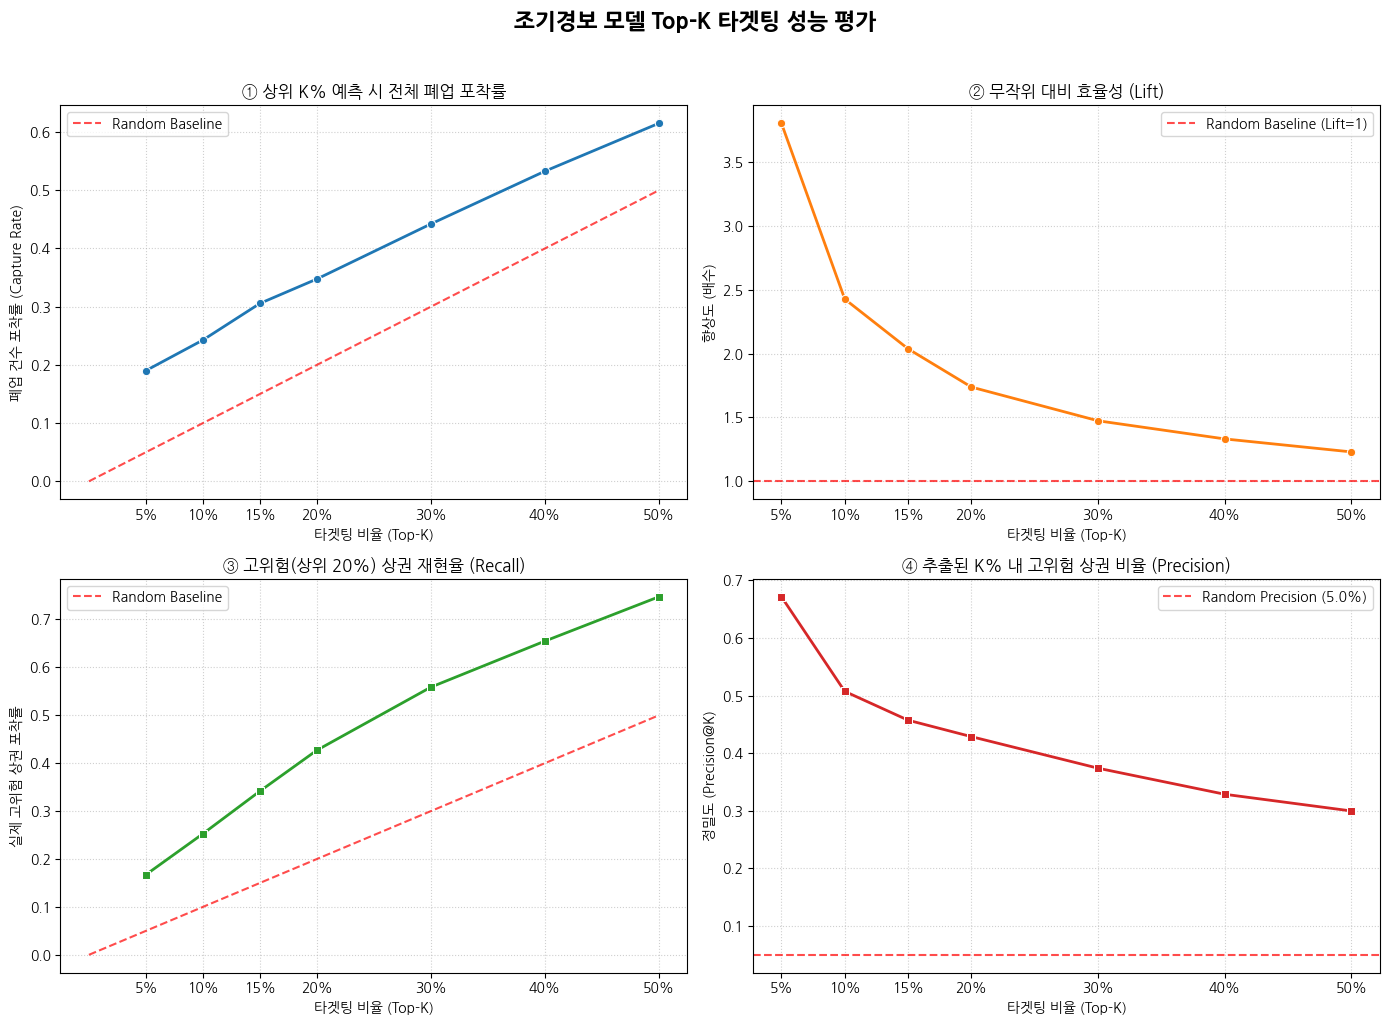

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터프레임 생성 (평가에는 OOF 예측값을 사용하는 것이 정석입니다)
ks_list = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5] # X축(Top-K) 범위를 조금 더 세밀하게 추가
count_df = topk_capture_count(df_train, 'pred_closure_rate_oof', ks=ks_list)
highrisk_df = topk_capture_highrisk(df_train, 'pred_closure_rate_oof', ks=ks_list)

def plot_topk_evaluation(count_df, highrisk_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('조기경보 모델 Top-K 타겟팅 성능 평가', fontsize=16, fontweight='bold', y=1.02)

    # 공통 X축 설정용
    x_ticks = count_df['top_k']
    x_labels = [f"{x*100:.0f}%" for x in x_ticks]

    # -----------------------------------------------------------
    # [1] 폐업 건수 기준 포착률 (Capture Rate)
    # -----------------------------------------------------------
    ax = axes[0, 0]
    sns.lineplot(data=count_df, x='top_k', y='capture_rate', marker='o', ax=ax, color='#1f77b4', linewidth=2)
    ax.plot([0, max(x_ticks)], [0, max(x_ticks)], 'r--', alpha=0.7, label='Random Baseline')

    ax.set_title('① 상위 K% 예측 시 전체 폐업 포착률', fontsize=12)
    ax.set_xlabel('타겟팅 비율 (Top-K)')
    ax.set_ylabel('폐업 건수 포착률 (Capture Rate)')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # -----------------------------------------------------------
    # [2] 폐업 건수 기준 향상도 (Lift)
    # -----------------------------------------------------------
    ax = axes[0, 1]
    sns.lineplot(data=count_df, x='top_k', y='lift', marker='o', ax=ax, color='#ff7f0e', linewidth=2)
    ax.axhline(1, color='r', linestyle='--', alpha=0.7, label='Random Baseline (Lift=1)')

    ax.set_title('② 무작위 대비 효율성 (Lift)', fontsize=12)
    ax.set_xlabel('타겟팅 비율 (Top-K)')
    ax.set_ylabel('향상도 (배수)')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # -----------------------------------------------------------
    # [3] 고위험 상권 (상위 20% GT) 포착률 (Recall)
    # -----------------------------------------------------------
    ax = axes[1, 0]
    sns.lineplot(data=highrisk_df, x='top_k', y='capture_rate', marker='s', ax=ax, color='#2ca02c', linewidth=2)
    ax.plot([0, max(x_ticks)], [0, max(x_ticks)], 'r--', alpha=0.7, label='Random Baseline')

    ax.set_title('③ 고위험(상위 20%) 상권 재현율 (Recall)', fontsize=12)
    ax.set_xlabel('타겟팅 비율 (Top-K)')
    ax.set_ylabel('실제 고위험 상권 포착률')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # -----------------------------------------------------------
    # [4] 고위험 상권 정밀도 (Precision @ K)
    # -----------------------------------------------------------
    ax = axes[1, 1]
    sns.lineplot(data=highrisk_df, x='top_k', y='precision_at_k', marker='s', ax=ax, color='#d62728', linewidth=2)

    # Random Precision = 전체 중 고위험 상권의 비율 (약 20%)
    random_precision = highrisk_df['capture_rate'].iloc[0] / highrisk_df['lift'].iloc[0]
    ax.axhline(random_precision, color='r', linestyle='--', alpha=0.7, label=f'Random Precision ({random_precision:.1%})')

    ax.set_title('④ 추출된 K% 내 고위험 상권 비율 (Precision)', fontsize=12)
    ax.set_xlabel('타겟팅 비율 (Top-K)')
    ax.set_ylabel('정밀도 (Precision@K)')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# 2. 함수 실행
plot_topk_evaluation(count_df, highrisk_df)

In [ ]:
import pandas as pd
from IPython.display import display

# 1. 폐업 건수(count_df)와 고위험 상권(highrisk_df) 결과 병합
merged_df = pd.merge(
    count_df[['top_k', 'n_markets', 'capture_rate', 'lift']],
    highrisk_df[['top_k', 'capture_rate', 'precision_at_k']],
    on='top_k',
    suffixes=('_closure', '_highrisk')
)

# 2. 보고서에 쓸 주요 K값만 필터링
target_ks = [0.05, 0.10, 0.20, 0.30]
table_df = merged_df[merged_df['top_k'].isin(target_ks)].copy()

# 3. 요청하신 양식에 맞게 포맷팅
table_df['위험도 상위 비율'] = table_df['top_k'].apply(lambda x: f"Top {int(x*100)}%")
table_df['상권 수'] = table_df['n_markets']
table_df['실제 폐업 포착률'] = table_df['capture_rate_closure'].apply(lambda x: f"{x*100:.1f}%")
table_df['Lift'] = table_df['lift'].apply(lambda x: f"{x:.2f}")
table_df['고위험 상권 포착률'] = table_df['capture_rate_highrisk'].apply(lambda x: f"{x*100:.1f}%")
table_df['Precision@k'] = table_df['precision_at_k'].apply(lambda x: f"{x*100:.1f}%")

# 4. 최종 컬럼 선택 및 출력
display_cols = ['위험도 상위 비율', '상권 수', '실제 폐업 포착률', 'Lift', '고위험 상권 포착률', 'Precision@k']
final_table = table_df[display_cols]

# Colab에서 보기 좋게 표 형태로 출력
display(final_table)

,위험도 상위 비율,상권 수,실제 폐업 포착률,Lift,고위험 상권 포착률,Precision@k
0,Top 5%,70,19.0%,3.80,16.7%,67.1%
1,Top 10%,140,24.3%,2.43,25.3%,50.7%
3,Top 20%,280,34.8%,1.74,42.7%,42.9%
4,Top 30%,420,44.2%,1.47,55.9%,37.4%
